### BERN02: Exercise Hierarchal models and Testing
Name: Johanna Rissbacher
Date: 24/09

#### Task
-Formulate and justify a parametric model for testing the effectiveness of the intervention <br>
-Estimate the model parameters <br>
-Test if the intervention has an effect or not <br>

In [ ]:
import pandas as pd
import bambi as bmb
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

##### Data wrangling

In [ ]:
# read in data
data_file = "towelData.csv"
data = pd.read_csv(data_file, sep=';', encoding='latin1')
count = data.iloc[:, -1] # get the last column with numbers or yes/no

# count has the number of yes and no for control and social norm groups
control_yes = count[::4].to_numpy() # every 4th starting from 0 - control group + yes
control_no = count[2::4].to_numpy() # every 4th starting from 2 - control group + no
control_total = np.array([y + n for y, n in zip(control_yes, control_no)])

social_yes = count[1::4].to_numpy() # every 4th starting from 1 - social norm group + yes
social_no = count[3::4].to_numpy() # every 4th starting from 3 - social norm group + no
social_total = np.array([y + n for y, n in zip(social_yes, social_no)])

study = np.arange(1,len(control_yes)+1) # 7 diferent studies

control_data = pd.DataFrame({"reuse": control_yes, "total": control_total, "group": "control", "study": study})
social_data = pd.DataFrame({ "reuse": social_yes, "total": social_total, "group": "social", "study": study})

df = pd.concat([control_data, social_data], ignore_index=True)

# Convert data types - important for bambi that they are correctly set 
# can give errors otherwise
df['reuse'] = df['reuse'].astype(int)
df['total'] = df['total'].astype(int)
df['group'] = df['group'].astype('category')
df['study'] = df['study'].astype('category')

#### Parametric model

The parametric model should test the effectiveness of the intervention. It should therefore model the number of successes (towel reused) in the sample of size n (total towels). Hence, the response variable can be modelled by a binomial distribution.

In [ ]:
# implementation of the model
model_hierarchical = bmb.Model("p(reuse, total) ~ group + (1|study)", df, family="binomial") # (1|study) accounts for the random effect of different studies
model_hierarchical

       Formula: p(reuse, total) ~ group + (1|study)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
            group ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5495))

In [ ]:
# fit the model, 2000 draws to ensure convergence
idata_hierarchical = model_hierarchical.fit(draw=2000)

In [173]:
# Summary of the parameter values by the posterior mean
stats_idata_hierarchical = az.summary(idata_hierarchical)
stats_idata_hierarchical['mean'] # output is a log-odds ratio

Intercept        0.393
group[social]    0.211
1|study_sigma    1.098
1|study[1]      -0.913
1|study[2]      -0.838
1|study[3]      -0.113
1|study[4]      -0.605
1|study[5]       1.158
1|study[6]       0.972
1|study[7]       0.782
p[0]             0.373
p[1]             0.391
p[2]             0.570
p[3]             0.448
p[4]             0.818
p[5]             0.796
p[6]             0.762
p[7]             0.424
p[8]             0.442
p[9]             0.620
p[10]            0.500
p[11]            0.847
p[12]            0.828
p[13]            0.798
Name: mean, dtype: float64

In [162]:
# posterior mean of the group effect (transform log-odds to odds ratio)
group_mean = round(np.exp(0.211),2)
group_mean

np.float64(1.23)

On average, the odds of reusing towels are 23% higher in the social-norm group compared to the control group.

In [170]:
# calculate the 90% HDI of the social norm group parameter
posterior_group = idata_hierarchical.posterior.group.values.flatten() # extract posterior samples for the group parameter and create 1D array
posterior_group_hdi90 = az.hdi(posterior_group, hdi_prob=0.90) # 90% HDI for the group parameter

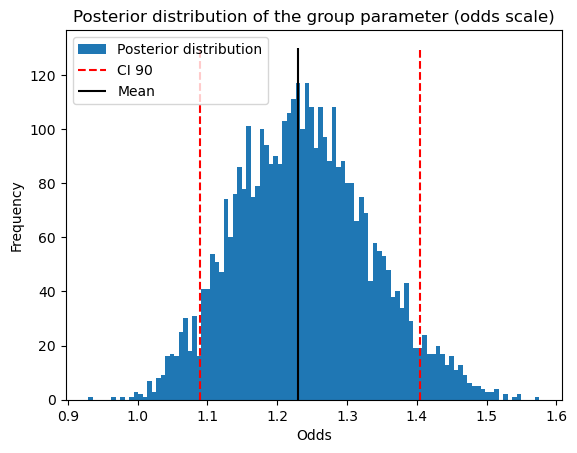

In [ ]:
# plot the posterior distribution of the group parameter with the 90% HDI and the posterior mean
plt.hist(np.exp(posterior_group), bins=100, label='Posterior distribution')
plt.vlines(np.exp(posterior_group_hdi90), ymin=0, ymax=130, colors='r', linestyles='--', label='CI 90') # 90% HDI
plt.vlines(group_mean, ymin=0, ymax=130, color='k', linestyle='-', label='Mean') # posterior mean
plt.xlabel('Probability')
plt.legend(loc='upper left')
plt.title('Posterior distribution of the group parameter (odds scale)')
plt.xlabel('Odds')
plt.ylabel('Frequency')
plt.show()

90% of the posterior odds ratios lie between 1.08 and 1.40, meaning the odds of reusing the towel are estimated to be 8–40% higher in the social norm group compared to the control group.

#### Test if the intervention has an effect or not

##### Hypothesis for the test: <br>


H0: The intervention has no effect <br>
H1: The intervention has an effect <br>

H0 will be rejected if p is very small and accepted if p $\approx 0.5$

In [ ]:
# calculate the Bayesian p-value
I_b = len(posterior_group[posterior_group < 0])
n = len(posterior_group)
p = 1/n * I_b
p

0.0015

The Bayesian p-value is p = 0.0015, which means the H0 will be rejected, hence the intervention has an effect. The statistical test shows that more people tend to reuse their towels, if there is a note which states that the majority of guests actually reused their towels in the past.